In [1]:
import pandas as pd
import io
from ipywidgets import FileUpload
from IPython.display import display

In [2]:
uploader = FileUpload(
    accept='.csv',
    multiple=False
)

In [3]:
#Upload the csv file
display(uploader)

FileUpload(value=(), accept='.csv', description='Upload')

In [4]:
#Make pandas read the csv files counting in tuples
if uploader.value:
    try:
        if isinstance(uploader.value, tuple) and len(uploader.value) > 0:
            first_item = uploader.value[0]
            if isinstance(first_item, dict) and 'content' in first_item:
                content = io.BytesIO(first_item['content'])
                df = pd.read_csv(content)
                print("File uploaded and dataframe created")
                print(df.head())
            elif isinstance(first_item, bytes):
                content = io.BytesIO(first_item)
                df = pd.read_csv(content)
                print("File uploaded and dataframe created")
                print(df.head())
            else:
                print(f"Unexpected structure of uploader.value[0]: {type(first_item)}")
        else:
            print(f"Unexpected structure of uploader.value[0]: {type(uploader.value)}")
            
    except Exception as e:
        print(f"An error occurred while reading the file: {e}")
else:
    print("No file uploaded.")

File uploaded and dataframe created
         REGISTRATION_DATE REGISTRATION_COUNTRY  PURCHASE_COUNT  \
0  2019-09-01 00:00:00.000                  DNK               0   
1  2019-09-01 00:00:00.000                  FIN               1   
2  2019-09-01 00:00:00.000                  DNK              19   
3  2019-09-01 00:00:00.000                  FIN               0   
4  2019-09-01 00:00:00.000                  GRC               0   

   PURCHASE_COUNT_DELIVERY  PURCHASE_COUNT_TAKEAWAY       FIRST_PURCHASE_DAY  \
0                      NaN                      NaN                      NaN   
1                      1.0                      0.0  2020-09-02 00:00:00.000   
2                     19.0                      0.0  2019-12-10 00:00:00.000   
3                      NaN                      NaN                      NaN   
4                      NaN                      NaN                      NaN   

         LAST_PURCHASE_DAY  USER_ID  BREAKFAST_PURCHASES  LUNCH_PURCHASES  \
0  

In [5]:
print(df.isnull().sum()) #Shows missing values in the dataframe

REGISTRATION_DATE                              0
REGISTRATION_COUNTRY                           0
PURCHASE_COUNT                                 0
PURCHASE_COUNT_DELIVERY                     9955
PURCHASE_COUNT_TAKEAWAY                     9955
FIRST_PURCHASE_DAY                         10019
LAST_PURCHASE_DAY                           9956
USER_ID                                        0
BREAKFAST_PURCHASES                         9955
LUNCH_PURCHASES                             9955
EVENING_PURCHASES                           9955
DINNER_PURCHASES                            9955
LATE_NIGHT_PURCHASES                        9955
TOTAL_PURCHASES_EUR                         9955
DISTINCT_PURCHASE_VENUE_COUNT               9955
MIN_PURCHASE_VALUE_EUR                      9955
MAX_PURCHASE_VALUE_EUR                      9955
AVG_PURCHASE_VALUE_EUR                      9955
PREFERRED_DEVICE                              73
IOS_PURCHASES                               9955
WEB_PURCHASES       

In [6]:
# Removing all the missing values in the dataframe

cols_to_fill_zero = [
    'PURCHASE_COUNT_DELIVERY', 'PURCHASE_COUNT_TAKEAWAY', 'BREAKFAST_PURCHASES',
    'LUNCH_PURCHASES', 'EVENING_PURCHASES', 'DINNER_PURCHASES',
    'LATE_NIGHT_PURCHASES', 'TOTAL_PURCHASES_EUR', 'DISTINCT_PURCHASE_VENUE_COUNT',
    'MIN_PURCHASE_VALUE_EUR', 'MAX_PURCHASE_VALUE_EUR', 'AVG_PURCHASE_VALUE_EUR',
    'IOS_PURCHASES', 'WEB_PURCHASES', 'ANDROID_PURCHASES', 'AVERAGE_DELIVERY_DISTANCE_KMS'
]
df[cols_to_fill_zero] = df[cols_to_fill_zero].fillna(0)

df['FIRST_PURCHASE_DAY'] = df['FIRST_PURCHASE_DAY'].fillna('Never Purchased')
df['LAST_PURCHASE_DAY'] = df['LAST_PURCHASE_DAY'].fillna('Never Purchased')
df['MOST_COMMON_HOUR_OF_THE_DAY_TO_PURCHASE'] = df['MOST_COMMON_HOUR_OF_THE_DAY_TO_PURCHASE'].fillna('No Purchase')
df['MOST_COMMON_WEEKDAY_TO_PURCHASE'] = df['MOST_COMMON_WEEKDAY_TO_PURCHASE'].fillna('No Purchase')
df['AVG_DAYS_BETWEEN_PURCHASES'] = df['AVG_DAYS_BETWEEN_PURCHASES'].fillna('Not Applicable')
df['MEDIAN_DAYS_BETWEEN_PURCHASES'] = df['MEDIAN_DAYS_BETWEEN_PURCHASES'].fillna('Not Applicable')

df['PREFERRED_RESTAURANT_TYPES'] = df['PREFERRED_RESTAURANT_TYPES'].fillna('Unknown')

In [7]:
df['PREFERRED_DEVICE'] = df['PREFERRED_DEVICE'].fillna(df['PREFERRED_DEVICE'].mode()[0])

In [8]:
print(df.isnull().sum()) #Shows that the missing values are now corrected

REGISTRATION_DATE                          0
REGISTRATION_COUNTRY                       0
PURCHASE_COUNT                             0
PURCHASE_COUNT_DELIVERY                    0
PURCHASE_COUNT_TAKEAWAY                    0
FIRST_PURCHASE_DAY                         0
LAST_PURCHASE_DAY                          0
USER_ID                                    0
BREAKFAST_PURCHASES                        0
LUNCH_PURCHASES                            0
EVENING_PURCHASES                          0
DINNER_PURCHASES                           0
LATE_NIGHT_PURCHASES                       0
TOTAL_PURCHASES_EUR                        0
DISTINCT_PURCHASE_VENUE_COUNT              0
MIN_PURCHASE_VALUE_EUR                     0
MAX_PURCHASE_VALUE_EUR                     0
AVG_PURCHASE_VALUE_EUR                     0
PREFERRED_DEVICE                           0
IOS_PURCHASES                              0
WEB_PURCHASES                              0
ANDROID_PURCHASES                          0
PREFERRED_

In [9]:
print(df.head())

         REGISTRATION_DATE REGISTRATION_COUNTRY  PURCHASE_COUNT  \
0  2019-09-01 00:00:00.000                  DNK               0   
1  2019-09-01 00:00:00.000                  FIN               1   
2  2019-09-01 00:00:00.000                  DNK              19   
3  2019-09-01 00:00:00.000                  FIN               0   
4  2019-09-01 00:00:00.000                  GRC               0   

   PURCHASE_COUNT_DELIVERY  PURCHASE_COUNT_TAKEAWAY       FIRST_PURCHASE_DAY  \
0                      0.0                      0.0          Never Purchased   
1                      1.0                      0.0  2020-09-02 00:00:00.000   
2                     19.0                      0.0  2019-12-10 00:00:00.000   
3                      0.0                      0.0          Never Purchased   
4                      0.0                      0.0          Never Purchased   

         LAST_PURCHASE_DAY  USER_ID  BREAKFAST_PURCHASES  LUNCH_PURCHASES  \
0          Never Purchased        1    

In [10]:
print(df.describe())

       PURCHASE_COUNT  PURCHASE_COUNT_DELIVERY  PURCHASE_COUNT_TAKEAWAY  \
count    21983.000000             21983.000000             21983.000000   
mean         3.345358                 3.141564                 0.203794   
std          8.523171                 8.301007                 1.063899   
min          0.000000                 0.000000                 0.000000   
25%          0.000000                 0.000000                 0.000000   
50%          1.000000                 1.000000                 0.000000   
75%          3.000000                 3.000000                 0.000000   
max        320.000000               320.000000                44.000000   

           USER_ID  BREAKFAST_PURCHASES  LUNCH_PURCHASES  EVENING_PURCHASES  \
count  21983.00000         21983.000000     21983.000000       21983.000000   
mean   10992.00000             0.106127         1.299504           0.269981   
std     6346.08982             0.822346         4.326257           1.374056   
min     

In [11]:
print(df['PURCHASE_COUNT'].mean())
print(df['TOTAL_PURCHASES_EUR'].median())
print(df['REGISTRATION_COUNTRY'].value_counts())

3.345357776463631
16.192
REGISTRATION_COUNTRY
FIN    10277
DNK     8081
GRC     3042
USA       70
GBR       54
SWE       45
EST       44
DEU       39
NOR       34
ITA       24
POL       23
LTU       22
ESP       19
CZE       14
FRA       11
BEL       11
HUN       11
AUS       11
NLD       10
ISR        9
RUS        8
CYP        7
IRL        7
IND        7
BRA        7
LVA        7
JPN        6
CAN        6
ARE        6
QAT        6
HRV        5
ROU        5
AUT        5
PRT        5
SGP        4
CHE        4
SVK        3
CHN        3
FRO        3
JOR        2
ISL        2
TUR        2
AZE        2
LBN        2
COL        2
UKR        2
CHL        2
TWN        1
PAK        1
KOR        1
SAU        1
PHL        1
GEO        1
MEX        1
HKG        1
GIN        1
KWT        1
MLT        1
SVN        1
Name: count, dtype: int64


In [12]:
subset_df = df[['REGISTRATION_COUNTRY', 'PURCHASE_COUNT', 'TOTAL_PURCHASES_EUR']]
print(subset_df.head())

  REGISTRATION_COUNTRY  PURCHASE_COUNT  TOTAL_PURCHASES_EUR
0                  DNK               0                0.000
1                  FIN               1               38.456
2                  DNK              19              631.488
3                  FIN               0                0.000
4                  GRC               0                0.000


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

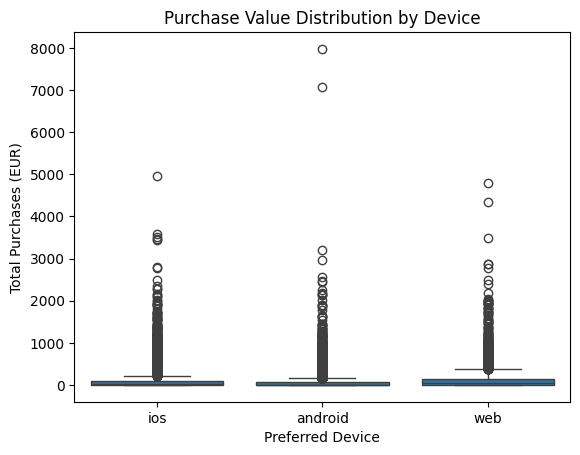

In [14]:
sns.boxplot(x='PREFERRED_DEVICE', y='TOTAL_PURCHASES_EUR', data=df)

plt.title('Purchase Value Distribution by Device')
plt.xlabel('Preferred Device')
plt.ylabel('Total Purchases (EUR)')
plt.show()

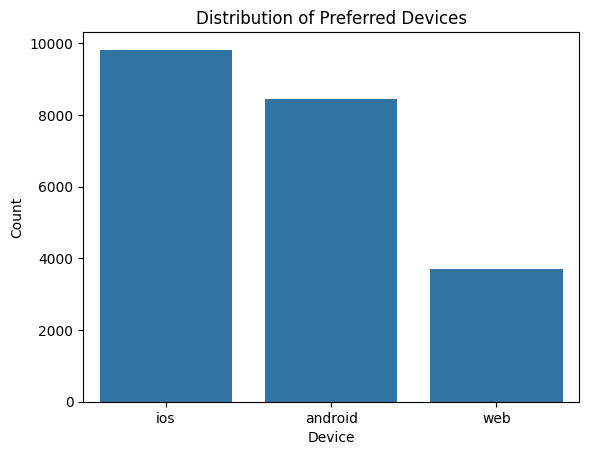

In [15]:
sns.countplot(x='PREFERRED_DEVICE', data=df)

plt.title('Distribution of Preferred Devices')
plt.xlabel('Device')
plt.ylabel('Count')
plt.show()